In [ ]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

# NB 3 - Creating masks of worms from videos using SAM 2

### OVERVIEW
The following notebook uses Meta's Segment Anything 2 (SAM2) to extract masks of worms from the background across experimental videos. We are presented with a frame and click to create four dots/points. The first two dots mark the animal and the second pair of dots should mark troubling features in the background -- the experimental electrodes by default, unless a particular shadow or dark area is giving the pipeline trouble. This pipeline requires access to experimental videos of individual worms. Furthermore, we re-mark the worm and background with a quartet across different chunks of a given video to refine the worm-isolating model to problematic sections of the video. These frames are marked in a CSV that lists a video name and a list of timestamps that define the chunks. The output of this pipeline is a .npz mask file and a complementary gif that the user can view to evaluate the quality of the mask just created.


The **mask files** are saved to "/n/holylabs/gershman_lab/Users/zkelso/Masks"

The **temporary gifs** are saved to "/n/netscratch/gershman_lab/Lab/zkelso/GIFS/"

The **CSV** used to create video chunks is "/n/holylabs/gershman_lab/Users/zkelso/video_splits.csv". Note that there is also a "fake_video_splits.csv" in the same location. The same videos must be entered into each CSV for the code to work. However, only video_splits.csv requires entries for frame ranges. The file fake_video_splits.csv does not require frame entries to work, hence the name.


When you are satisfied with the mask chunks you have created, proceed to **Notebook 4** to join your mask fragments into a single FINAL mask and to extract features (area, perimeter, etc.) from the mask for statistical analysis.

### HOW TO USE
Ensure that your session has video files and raw data uploaded to the server and that your video has its session ID entered in to the sessions_to_process list. Proceed through the notebook until you reach the penultimate codeblock. Run that block, select your two worm and two background points, then press enter. When the code creates a gif of a mask made from your four points propagated through the rest of the video (see directories above), review that mask. At any point where the mask integrity/fidelity is lost and *does not return*, identify the next frame where the worm is no longer occluded. Enter that frame range into the video_splits.csv entry for the video, then run the final codeblock (different than the one you just ran!). You will be prompted to repeat drawing points for each chunk in video_splits.csv. Continually run and re-run the final block, entering new chunk ranges in video_splits.csv according to mask fidelity, until you have good masks spanning the entire video. Run Notebook 4 to create the final mask for that video, then return to Notebok 3 (this notebook) to make masks for a new video.

# Video segmentation with SAM 2

This notebook is based off of video_predictor_example. To deal with long periods of occlusion, we splice the session video into sections of un-occluded and occluded, and separately propagate labels through each one. We then stitch the video back together at the end to get a full timeseries of the masked worm. 

This notebook has been further modified to take a list of session names (timestamp folder name containing bin file). The code loops through each folder entity (widget video 1 --> process video 1 --> widget video 2 --> process video 2 --> etc.) until the list has been iterated through.

## Environment Set-up

In [1]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import io
import imageio
from pathlib import Path
import math
import csv
import ast
import pdb

print("Packages loaded. Proceed.")

Packages loaded. Proceed.


In [2]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


# For a given session, find the videos/jpgs that don't yet have QC'd masks.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# SESSION LIST - Edit this to process multiple sessions
# ═══════════════════════════════════════════════════════════════════════════

# TP-3
sessions_to_process = [
#'2025_10_14_10_25_19_trial_1_TC',
#'2025_10_14_14_13_15_trial_1_TC',
#'2025_10_15_10_09_28_trial_1_TC',
#'2025_10_15_14_16_21_trial_1_TC',
#'2025_10_16_09_59_15_trial_1_TC',
#'2025_10_16_14_12_17_trial_1_TC',
#'2025_10_17_10_05_03_trial_1_TC',
#'2025_10_17_14_18_23_trial_1_TC',
# '2025_10_14_10_47_52_trial_1_TP', # Done
'2025_10_14_14_35_32_trial_1_TP' # WIP
#'2025_10_15_10_37_01_trial_1_TP',
#'2025_10_15_14_43_14_trial_1_TP',
#'2025_10_16_10_24_06_trial_1_TP', # Done
#'2025_10_16_14_48_01_trial_1_TP', # Sage WIP
#'2025_10_17_10_34_57_trial_1_TP', # Sage WIP
#'2025_10_17_14_45_34_trial_1_TP'  # Done
]


# TP-4
# sessions_to_process = []


# TC-6
# sessions_to_process = []


# TC-7
# sessions_to_process = []



use_prior_labels = True
use_boxes = False

# ═══════════════════════════════════════════════════════════════════════════
# Path setup
# ═══════════════════════════════════════════════════════════════════════════

holylabs_base = "/n/holylabs/gershman_lab/Users/zkelso/Raw_data/"
masks_base = "/n/holylabs/gershman_lab/Users/zkelso/Masks/"
gifs_base = "/n/netscratch/gershman_lab/Lab/zkelso/GIFs/"
boxes_base = "/n/holylabs/gershman_lab/Users/zkelso/DLC_Projects/WormTracking/labeled_data/"
# Choose where to look for video folders (uncomment one):
video_folders_base = "/n/netscratch/gershman_lab/Lab/zkelso/temporary_jpgs/unlabeled-data"
video_split_csv = "/n/holylabs/gershman_lab/Users/zkelso/video_splits.csv"
fake_split_csv = "/n/holylabs/gershman_lab/Users/zkelso/fake_video_splits.csv"


# ═══════════════════════════════════════════════════════════════════════════
# Find and check videos for all sessions
# ═══════════════════════════════════════════════════════════════════════════

done_session_worms = []
to_process = []

for session in sessions_to_process:
    print(f"\n{'='*80}")
    print(f"Checking session: {session}")
    print(f"{'='*80}")
    
    # Path to this session's folder
    session_folder = Path(video_folders_base) / session
    
    # Check if session folder exists
    if not session_folder.exists():
        print(f"WARNING: Session folder not found at {session_folder}")
        continue
    
    # Find all video folders inside this session (ending with _fullvideo)
    video_folders = list(session_folder.glob("*_fullvideo"))
    
    if video_folders:
        print(f"Found {len(video_folders)} video folder(s):")
        for folder in video_folders:
            print(f"  - {folder.name}")
    else:
        print(f"No video folders (*_fullvideo) found in {session}")
        continue
    
    # Check each video folder
    for video_folder in video_folders:
        print(f"\nChecking: {video_folder.name}")
        
        # Check 1: Does it have JPG files?
        jpg_count = sum(1 for f in video_folder.iterdir() 
                       if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg"])
        has_jpgs = jpg_count > 100
        
        if has_jpgs:
            print(f"  [OK] JPG files: {jpg_count} frames")
        else:
            print(f"  [X] JPG files: Only {jpg_count} frames (need >100)")
            continue  # Skip this video
        
        # Check 2: Does it already have a mask file?
        npz_filename1 = f"{video_folder.name}_frame_split_FINAL_points_binary_masks.npz"
        npz_filename2 = f"{video_folder.name}_FINAL_boxes_binary_masks.npz"
        npz_path1 = Path(masks_base) / npz_filename1; npz_path2 = Path(masks_base) / npz_filename2

        if npz_path1.exists():
            print(f"  [OK] Mask exists: {npz_filename1}")
            done_session_worms.append(str(npz_path1))
        elif npz_path2.exists():
            print(f"  [OK] Mask exists: {npz_filename2}")
            done_session_worms.append(str(npz_path2))
        else:
            print(f"  [PROCESS] Mask not found: {npz_filename1}")
            to_process.append(str(video_folder))  # Add full path to video folder

# ═══════════════════════════════════════════════════════════════════════════
# Summary
# ═══════════════════════════════════════════════════════════════════════════

print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
print(f"\nProcessed {len(sessions_to_process)} session(s)")
print(f"Total videos found: {len(done_session_worms) + len(to_process)}")
print(f"  Already have masks: {len(done_session_worms)}")
print(f"  Need processing: {len(to_process)}")

if to_process:
    print(f"\nVideos to process:")
    for video_path in to_process:
        print(f"  - [ ] {Path(video_path).name}")

if to_process and len(done_session_worms) == 0:
    print("\n\nCopy this to video_splits.csv and fake_video_splits.csv:\n")
    
    for video_path in to_process:
        video_hook = Path(video_path).name
        print(f"{Path(video_hook).name.split('_fullvideo')[0]},[],[]")
      



Checking session: 2025_10_14_14_35_32_trial_1_TP
Found 6 video folder(s):
  - 2025_10_14_14_35_32_trial_1_TP_regions_1093_428_1336_1356_fullvideo
  - 2025_10_14_14_35_32_trial_1_TP_regions_1341_417_1580_1343_fullvideo
  - 2025_10_14_14_35_32_trial_1_TP_regions_147_468_383_1396_fullvideo
  - 2025_10_14_14_35_32_trial_1_TP_regions_391_473_620_1393_fullvideo
  - 2025_10_14_14_35_32_trial_1_TP_regions_615_441_862_1375_fullvideo
  - 2025_10_14_14_35_32_trial_1_TP_regions_859_449_1104_1380_fullvideo

Checking: 2025_10_14_14_35_32_trial_1_TP_regions_1093_428_1336_1356_fullvideo
  [OK] JPG files: 1799 frames
  [OK] Mask exists: 2025_10_14_14_35_32_trial_1_TP_regions_1093_428_1336_1356_fullvideo_frame_split_FINAL_points_binary_masks.npz

Checking: 2025_10_14_14_35_32_trial_1_TP_regions_1341_417_1580_1343_fullvideo
  [OK] JPG files: 1799 frames
  [OK] Mask exists: 2025_10_14_14_35_32_trial_1_TP_regions_1341_417_1580_1343_fullvideo_frame_split_FINAL_points_binary_masks.npz

Checking: 2025_10_14_

PROCESSING: 2025_10_14_14_35_32_trial_1_TP_regions_391_473_620_1393_fullvideo


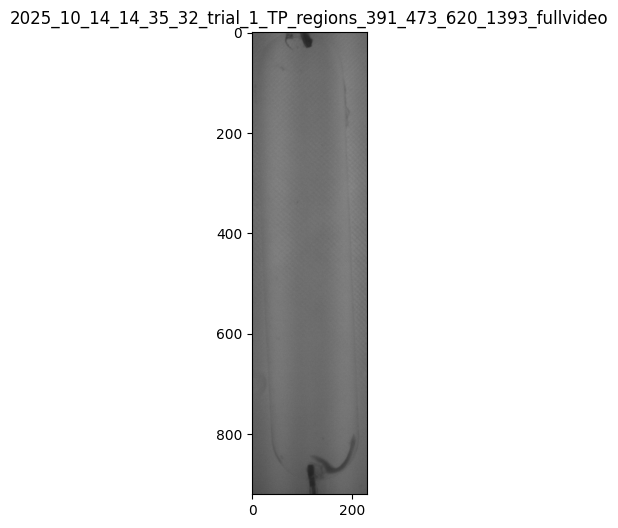

In [4]:
# ======= CONFIGURE WHICH VIDEO TO PROCESS HERE ===============================

for i in to_process:
    npz_path = masks_base + str(i.split('/')[-1:][0])+'_binary_masks.npz'
    
    if os.path.exists(npz_path):
        to_process.remove(npz_path)
    else:
        CURRENT_VIDEO = str(i.split('/')[-1:][0])
        print("PROCESSING: "+ CURRENT_VIDEO)
        break

make_gif = True



# ======== NO NEED TO EDIT BELOW THIS LINE ===============================================================================

# Split regions out of video name to use in file path reconstruction
current_video_folder = CURRENT_VIDEO.split("_regions")[0]

# Create strings to reconstruct video pathway
video_dir = f"{video_folders_base}/{current_video_folder}/{CURRENT_VIDEO}"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))
#2025_10_14_10_25_19_trial_1_TC_regions_1072_463
# take a look the first video frame to make sure it's kind of what you want
frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"{CURRENT_VIDEO}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

# Define functions

In [5]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

# Mouse callback remains the same
def pick_point(event, x, y, flags, param):
    curr_img, curr_coords, w_name = param
    event_counter=0
    if event == cv2.EVENT_LBUTTONDOWN:
        curr_coords.append([x, y])
        if event_counter>2:
            cv2.circle(curr_img, (x, y), 7, (0, 0, 255), -1)
        elif event_counter<3:
            cv2.circle(curr_img, (x, y), 7, (0, 255, 0), -1)
        else:
            print("Click events exceeded 4. Redo")
            return
               
        event_counter+=1
        cv2.putText(curr_img, str(len(curr_coords)), (x + 10, y + 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        cv2.imshow(w_name, curr_img)

def get_points_and_labels(frame,video_dir,frame_names):
            
    img_path = os.path.join(video_dir, frame_names[frame])
    print(f"Loading: {frame_names[frame]}")
    
    image = cv2.imread(img_path)
    if image is None:
        print(f"Failed to load {img_path}")
        return
        
    display_img = image.copy()
    clicked_coords = []
    
    window_name = f"Frame {frame_names[frame]} - Add two points, subtract two points --> Enter"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(window_name, 1600, 1000)
    
    # Set callback with the specific display_img for THIS frame
    cv2.setMouseCallback(window_name, pick_point, [display_img, clicked_coords, window_name])  
    
    # Show the NEW image
    cv2.imshow(window_name, display_img)

    # Wait for keypress
    cv2.waitKey(0)
    
    # Clean up THIS specific window
    cv2.destroyWindow(window_name)
    cv2.waitKey(1) 

    points = np.array(clicked_coords, dtype=np.float32)

    labels = np.array([1,1,0,0], dtype=np.int32)

    return points,labels

def update_frame_data(file_path, frame_idx, coordinates):
    # 1. Check if file exists; if not, create an empty dict and save it
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Creating new database...")
        data = {}
        np.save(file_path, data) 
    
    # 2. Load the existing dictionary
    # we use .item() to pull the dictionary out of the numpy wrapper
    data = np.load(file_path, allow_pickle=True).item()

    # 3. Check if frame is missing and update
    if frame_idx not in data:
        data[frame_idx] = coordinates
        # 4. Save back to disk
        np.save(file_path, data)
        print(f"Frame {frame_idx} successfully saved to {file_path}.")
    else:
        print(f"Frame {frame_idx} is already in the file. No changes made.")


def get_boxes(frame, video_dir, frame_names, start, all_labeled_frames_path):
    img_path = os.path.join(video_dir, frame_names[frame])
    image = cv2.imread(img_path)
    if image is None: 
        print(f"Error: Could not load {img_path}")
        return None, None, None

    window_name = f"Frame {frame} | 1. GREEN: OBJECT -> ENTER | 2. RED: BACKGROUND -> ENTER"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(window_name, 1600, 1000)

    # --- STEP 1: Positive Box (The Object) ---
    # Drag green box, then press ENTER or SPACE
    roi_pos = cv2.selectROI(window_name, image, showCrosshair=True)
    pos_box = np.array([roi_pos[0], roi_pos[1], roi_pos[0] + roi_pos[2], roi_pos[1] + roi_pos[3]], dtype=np.float32)

    # Draw the green box on a copy to show the user what they already selected
    display_img = image.copy()
    cv2.rectangle(display_img, (roi_pos[0], roi_pos[1]), 
                  (roi_pos[0]+roi_pos[2], roi_pos[1]+roi_pos[3]), (0, 255, 0), 3)

    # --- STEP 2: Negative Box (Background exclusion) ---
    # Drag red box, then press ENTER or SPACE. If no background box is needed, just press ENTER.
    roi_neg = cv2.selectROI(window_name, display_img, showCrosshair=True)
    
    # --- STEP 3: Convert Negative Box to Grid ---
    neg_points = []
    if roi_neg[2] > 0 and roi_neg[3] > 0:
        x_coords = np.linspace(roi_neg[0], roi_neg[0] + roi_neg[2], 3)
        y_coords = np.linspace(roi_neg[1], roi_neg[1] + roi_neg[3], 3)
        for x in x_coords:
            for y in y_coords:
                neg_points.append([x, y])

    cv2.destroyWindow(window_name)
    cv2.waitKey(1)

    # Convert to SAM 2 Format
    # If no negative box was drawn, we return an empty array of the correct shape
    if len(neg_points) > 0:
        final_points = np.array(neg_points, dtype=np.float32)
        final_labels = np.zeros(len(neg_points), dtype=np.int32)
    else:
        final_points = np.empty((0, 2), dtype=np.float32)
        final_labels = np.empty((0,), dtype=np.int32)

    # --- STEP 4: Persistent Save ---
    frame_data = {
        "points": final_points,
        "labels": final_labels,
        "box": pos_box
    }

    # Use the path passed in from the main loop
    update_frame_data(all_labeled_frames_path, frame, frame_data)

    return final_points, final_labels, pos_box


def dynamically_add_points(frame_list, prop_len, video_dir, frame_names, predictor, inference_state, start_frame, end_frame, mode="add"):
            
    for frame in frame_list:
        img_path = os.path.join(video_dir, frame_names[frame])
        print(f"Loading: {frame_names[frame]} (Frame {frame})")
        
        image = cv2.imread(img_path)
        if image is None:
            print(f"Failed to load {img_path}")
            return
            
        display_img = image.copy()
        clicked_coords = []
        
        window_name = f"Frame {frame} - Add two points, subtract two points --> Enter"
        cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
        cv2.resizeWindow(window_name, 1600, 1000)
        
        # Set callback with the specific display_img for THIS frame
        cv2.setMouseCallback(window_name, pick_point, [display_img, clicked_coords, window_name, mode])  
        
        # Show the NEW image
        cv2.imshow(window_name, display_img)
    
        # Wait for keypress
        cv2.waitKey(0)
        
        # Clean up THIS specific window
        cv2.destroyWindow(window_name)
        cv2.waitKey(1) 
    
        points = np.array(clicked_coords, dtype=np.float32)

        labels = np.array([1,1,0,0], dtype=np.int32)

        if clicked_coords == []:
            return
        else:
            _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
                inference_state=inference_state,
                frame_idx=frame,
                obj_id=ann_obj_id,
                points=points,
                labels=labels,
            )
        
            # show the results on the current (interacted) frame
            plt.figure(figsize=(9, 6))
            plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame])))
            show_points(points, labels, plt.gca())
            show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

    # Outside the original frames loop, run propagation throughout the video and collect the results in a dict
    video_segments = {}  # video_segments contains the per-frame segmentation results
    for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(
        inference_state, 
        start_frame_idx=start_frame, # Force it to start from the beginning
        max_frame_num_to_track=end_frame-start_frame+1, 
        reverse=False
    ):
        video_segments[out_frame_idx] = {
            out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
            for i, out_obj_id in enumerate(out_obj_ids)
        }
        
    return video_segments


def display_new_frames(vis_frame_stride,start_frame,end_frame,video_dir,frame_names,video_segments):
    # visualize the segmentation results every few frames
    #plt.close("all")
    for out_frame_idx in range(start_frame,end_frame, vis_frame_stride):
        plt.figure(figsize=(6, 4))
        plt.title(f"frame {out_frame_idx}")
        plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
        for out_obj_id, out_mask in video_segments[out_frame_idx].items():
            show_mask(out_mask, plt.gca(), obj_id=out_obj_id)


def make_a_gif(frame_names,video_dir,video_segments,output_path,start_frame):

    gif_frames = []
    vis_frame_stride = 1

    # Optional: define which frames to process. 
    # Using range(0, len(frame_names)) might take a long time if the video is long.
    for out_frame_idx in range(1, len(video_segments), vis_frame_stride):
        out_frame_idx = start_frame + out_frame_idx
        # Create a wider figure for two subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
        
        # Load the base image once
        img_path = os.path.join(video_dir, frame_names[out_frame_idx])
        raw_image = Image.open(img_path)
        
        # --- Left Plot: Original Image ---
        ax1.imshow(raw_image)
        ax1.set_title(f"Original Frame {out_frame_idx}")
        ax1.axis('off') # Hide tick marks for a cleaner look
        
        # --- Right Plot: Image + Segmentation ---
        ax2.imshow(raw_image)
        #for out_obj_id, out_mask in enumerate(video_segments[out_frame_idx].items():
        for out_mask in video_segments[out_frame_idx]:
            show_mask(out_mask, ax2, obj_id=1)
        ax2.set_title(f"Segmentation {out_frame_idx}")
        ax2.axis('off')
        
        # Standardize layout
        plt.tight_layout() 
        
        # Save to buffer
        buf = io.BytesIO()
        plt.savefig(buf, format='png') 
        buf.seek(0)
        
        # Read back and store
        img = imageio.v2.imread(buf)
        gif_frames.append(img)
        
        # Clean up memory
        plt.close(fig)
    
    # Save the side-by-side GIF
    imageio.mimsave(output_path+'_GIF.gif', gif_frames, fps=13, loop=0)
    
    print(f"Side-by-side GIF saved successfully at: {output_path}")


def _parse_bracket_lists(s):
    """
    From a string like "[510,1111,1270],[580,1170,1450]"
    return [[510,1111,1270], [580,1170,1450]].
    """
    import re
    # find all things inside [...]
    groups = re.findall(r"\[(.*?)\]", s)
    lists = []
    for g in groups:
        g = g.strip()
        if not g:
            lists.append([])
            continue
        parts = [p.strip() for p in g.split(",") if p.strip() != ""]
        lists.append([int(p) for p in parts])
    return lists


def get_values_for_date(csv_path, target_date):
    """
    Read a CSV of format:
        name, [start1, start2, ...]           # old format (1 list)
    or:
        name, [start1, start2, ...], [end1, end2, ...]   # new format (2 lists)

    `target_date` is something like "..._fullvideo_points_GIF";
    we match the part before '_fullvideo'.

    Returns:
        start_frames (list of ints), stop_frames (list of ints)
    """
    base_name = target_date.split("_fullvideo")[0]

    with open(csv_path, newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            if not row:
                continue

            name = row[0].strip()
            if name != base_name:
                continue

            # Re-join the rest of the columns so we can parse the bracketed lists
            rest = ",".join(row[1:]).strip()
            lists = _parse_bracket_lists(rest)

            if not lists:
                # no lists at all
                split_starts, split_ends = [], []
            elif len(lists) == 1:
                split_starts = lists[0]
                split_ends = [f - 1 for f in split_starts]
            else:
                split_starts, split_ends = lists[0], lists[1]

            if (len(split_starts) == 0) & (len(split_ends) == 0):
                split_starts = [0]
                split_ends = [1799]
                
            return split_starts, split_ends

    raise ValueError(f"Video name {base_name!r} not found in CSV.")

# Load SAM2 video predictor

In [6]:
from sam2.build_sam import build_sam2_video_predictor

# Maddie path vs. Zach path
sam2_checkpoint = "/n/holylabs/gershman_lab/Users/zkms/sam_checkpoints/sam2.1_hiera_large.pt"


model_cfg = "//n/holylabs/gershman_lab/Users/zkms/sam_checkpoints/sam2.1_hiera_l.yaml"


# Initialize one predictor
predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

print("Loaded video predictor.")

Loaded video predictor.


# Begin iterative refinement training loop. 

### Here you can use boxes or points, depending on which one works better.

In [13]:
frame_split_starts,frame_split_ends = get_values_for_date(fake_split_csv, CURRENT_VIDEO)

i=0
first_frame_idx = frame_split_starts[i]  # The start of your video
last_frame_idx = frame_split_ends[i]
all_points_path = boxes_base + CURRENT_VIDEO + 'frame_start_'+str(frame_split_starts)+'_SAM_points.npy'
all_video_segments = {} # To store the results

# 1. Initialize the predictor state
inference_state = predictor.init_state(video_path=video_dir)

# 2. Get points from the UI for the first frame
# We use your existing get_points_and_labels function
points, labels = get_points_and_labels(first_frame_idx, video_dir, frame_names)

# 3. Format and Save to the .npy file (Dictionary format)
# We set 'box' to None or an empty list so it matches the dictionary structure
frame_bundle = {
    "points": points,
    "labels": labels,
    "box": None  # No box for this specific prompt
}

#update_frame_data(all_points_path, first_frame_idx, end_frame_idx, frame_bundle)

# Safety check: Match labels length to the number of points actually clicked
if len(points) != len(labels):
    print(f"Adjusting labels: you clicked {len(points)} points.")
    # Create 1s for the first few and 0s for the rest, or just all 1s if only 1-2 points
    labels = np.ones(len(points), dtype=np.int32) 
    if len(points) > 2:
        labels[2:] = 0 # Assume 3rd and 4th clicks are negative labels

# 3. Add the points to the predictor
predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=first_frame_idx,
    obj_id=1,
    points=points,
    labels=labels,
)

# 4. Propagate through the entire video
print("Propagating through the full video... this may take a moment.")
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    # Store the mask (thresholded at 0.0)
    all_video_segments[out_frame_idx] = (out_mask_logits[0] > 0.0).cpu().numpy()

# 5. Clean up
# predictor.reset_state(inference_state) # Uncomment if you want to clear memory immediately
all_video_segments = {k: all_video_segments[k] for k in range(frame_split_starts[i], frame_split_ends[i])}
print(f"Propagation complete. {len(all_video_segments)} frames processed. Saving gif...")

if make_gif == True:
    output_path = gifs_base + CURRENT_VIDEO + '_frame_split_'+str(frame_split_starts[i])+'_points'
    make_a_gif(frame_names,video_dir,all_video_segments,output_path,frame_split_starts[i])

# 1. Sort the frames to ensure chronological order
sorted_frames = sorted(all_video_segments.keys())

# 2. Stack them into a single 4D array: (Frames, Channels, Height, Width)
# Current shape is (1, 936, 260), so result will be (N, 1, 936, 260)
mask_stack = np.stack([all_video_segments[f] for f in sorted_frames])

# 3. Save as a compressed file
out_path =  masks_base + CURRENT_VIDEO + '_frame_split_'+ str(frame_split_starts[i])+'_'+str(frame_split_ends[i])+'_points_binary_masks.npz'
np.savez_compressed(out_path, masks=mask_stack)
    

frame loading (JPEG): 100%|█████████████████| 1799/1799 [00:39<00:00, 45.23it/s]


Loading: 00000.jpeg


/n/home02/zkelso/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/n/home02/zkelso/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


Propagating through the full video... this may take a moment.


propagate in video: 100%|███████████████████| 1799/1799 [00:35<00:00, 51.30it/s]


Propagation complete. 1799 frames processed. Saving gif...
Side-by-side GIF saved successfully at: /n/netscratch/gershman_lab/Lab/zkelso/GIFs/2025_10_14_14_35_32_trial_1_TP_regions_147_468_383_1396_fullvideo_frame_split_0_points


In [ ]:
frame_split_starts,frame_split_ends = get_values_for_date(video_split_csv, CURRENT_VIDEO)

for i,item in enumerate(frame_split_starts): # JPEG shit starts here at earliest
    
    # --- Configuration ---
    first_frame_idx = frame_split_starts[i]  # The start of your video
    last_frame_idx = frame_split_ends[i]
    all_points_path = boxes_base + CURRENT_VIDEO + 'frame_start_'+str(frame_split_starts)+'_SAM_points.npy'
    all_video_segments = {} # To store the results
    
    # 1. Initialize the predictor state
    inference_state = predictor.init_state(video_path=video_dir)
    
    # 2. Get points from the UI for the first frame
    # We use your existing get_points_and_labels function
    points, labels = get_points_and_labels(first_frame_idx, video_dir, frame_names)
    
    # 3. Format and Save to the .npy file (Dictionary format)
    # We set 'box' to None or an empty list so it matches the dictionary structure
    frame_bundle = {
        "points": points,
        "labels": labels,
        "box": None  # No box for this specific prompt
    }
    
    #update_frame_data(all_points_path, first_frame_idx, end_frame_idx, frame_bundle)
    
    # Safety check: Match labels length to the number of points actually clicked
    if len(points) != len(labels):
        print(f"Adjusting labels: you clicked {len(points)} points.")
        # Create 1s for the first few and 0s for the rest, or just all 1s if only 1-2 points
        labels = np.ones(len(points), dtype=np.int32) 
        if len(points) > 2:
            labels[2:] = 0 # Assume 3rd and 4th clicks are negative labels
    
    # 3. Add the points to the predictor
    predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=first_frame_idx,
        obj_id=1,
        points=points,
        labels=labels,
    )
    
    # 4. Propagate through the entire video
    print("Propagating through the full video... this may take a moment.")
    for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
        # Store the mask (thresholded at 0.0)
        all_video_segments[out_frame_idx] = (out_mask_logits[0] > 0.0).cpu().numpy()
    
    # 5. Clean up
    # predictor.reset_state(inference_state) # Uncomment if you want to clear memory immediately
    all_video_segments = {k: all_video_segments[k] for k in range(frame_split_starts[i], frame_split_ends[i])}
    print(f"Propagation complete. {len(all_video_segments)} frames processed. Saving gif...")

    if make_gif == True:
        output_path = gifs_base + CURRENT_VIDEO + '_frame_split_'+str(frame_split_starts[i])+'_points'
        make_a_gif(frame_names,video_dir,all_video_segments,output_path,frame_split_starts[i])

    # 1. Sort the frames to ensure chronological order
    sorted_frames = sorted(all_video_segments.keys())
    
    # 2. Stack them into a single 4D array: (Frames, Channels, Height, Width)
    # Current shape is (1, 936, 260), so result will be (N, 1, 936, 260)
    mask_stack = np.stack([all_video_segments[f] for f in sorted_frames])
    
    # 3. Save as a compressed file
    out_path =  masks_base + CURRENT_VIDEO + '_frame_split_'+ str(frame_split_starts[i])+'_'+str(frame_split_ends[i])+'_points_binary_masks.npz'
    np.savez_compressed(out_path, masks=mask_stack)


frame loading (JPEG): 100%|█████████████████| 1799/1799 [00:40<00:00, 44.84it/s]


Loading: 00000.jpeg


/n/home02/zkelso/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/n/home02/zkelso/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


Propagating through the full video... this may take a moment.


propagate in video: 100%|███████████████████| 1799/1799 [00:35<00:00, 50.86it/s]


Propagation complete. 1799 frames processed. Saving gif...
